In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image

REPO = Path(".").resolve()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from raw_optimizer.dfront_ct import (
    render_scene, decompose_scene, render_3dfront_dataset
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {DEVICE}")


c:\Users\felix\miniconda3\envs\torch311\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


device: cuda


In [3]:
from raw_optimizer.dfront_ct import render_scene, decompose_scene
from pathlib import Path

root = Path(r"E:\3D-Front\output")
SCENE_ID = "e603120f-692f-4553-97e3-71e940cc0542"
# SCENE_ID = "76347b63-6e7e-419e-89b3-0fa82279515f"
LIGHT_NR = 0
SCENE_DIR = root / SCENE_ID / str(LIGHT_NR)
DFRONT_ROOT = Path("results") / "3dfront" / SCENE_ID / str(LIGHT_NR)

CFG = dict(n_iter=100, lbfgs_max_iter=10, log_every=5)


## 9 -- 3D-Front scene: render + CT decomposition

The scene `00ad8345` provides GT albedo, normals, roughness, metallic maps
and 16 pre-rendered images under different lighting conditions.

Since no mesh or depth map is available, a proxy perspective geometry is
constructed from the normal map: the camera is placed at `(0, 0, 2)` and
fragments are distributed on the `z=0` plane according to `fov_deg=60`.

**9a** -- render from GT maps under a 45 deg directional SH (CT-SH and CT-ENV)
**9b** -- decompose the 16 observed images with CT-SH
**9c** -- decompose with CT-ENV
**9d** -- decompose with CT-SH + TV regularization (lambda_tv = 1e-3)
**9e** -- inspect results

In [4]:
# -- 9a: render from GT material maps + directional SH --------
for shader in ("ct_sh", "ct_env"):
    render_scene(
        SCENE_DIR, DFRONT_ROOT / f"rendered_az10_{shader}",
        az_deg=10.0, el_deg=0.0, shader=shader, device=DEVICE
    )
print("done: renders")

Rendered 124x124 -> results\3dfront\e603120f-692f-4553-97e3-71e940cc0542\0\rendered_az10_ct_sh\render.png
Rendered 124x124 -> results\3dfront\e603120f-692f-4553-97e3-71e940cc0542\0\rendered_az10_ct_env\render.png
done: renders


In [5]:
# -- 9b: CT-SH decomposition -----------------------------------------
decompose_scene(
    SCENE_DIR, DFRONT_ROOT / "ct_sh",
    shader="ct_sh",
    cfg_overrides={**CFG, "n_iter": 100},
    log_gradients=True, device=DEVICE,
    wandb_project="3d-front-decomposition"
)
print("done: CT-SH decomp")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\felix\_netrc.
wandb: Currently logged in as: flaarmann (adlr-latents) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


KeyboardInterrupt: 

In [ ]:
# -- 9c: CT-ENV decomposition ----------------------------------------
decompose_scene(
    SCENE_DIR, DFRONT_ROOT / "ct_env",
    shader="ct_env",
    cfg_overrides={**CFG, "n_iter": 100},
    log_gradients=True, device=DEVICE,
)
print("done: CT-ENV decomp")

In [ ]:
# -- 9d: CT-SH + TV regularization -----------------------------------
decompose_scene(
    SCENE_DIR, DFRONT_ROOT / "ct_sh_tv1e-3",
    shader="ct_sh",
    cfg_overrides={**CFG, "n_iter": 100, "lambda_tv": 1e-3},
    log_gradients=True, device=DEVICE,
)
print("done: CT-SH + TV decomp")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\felix\_netrc.
wandb: Currently logged in as: flaarmann (adlr-latents) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  [init]          loss=2.404e+00  data=2.404e+00  metallic=0.500  roughness=0.500


wandb: WARNING Tried to log to step -1 that is less than the current step 0. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


  [   0]    4.0s  loss=1.432e-01  data=1.432e-01  metallic=0.502  roughness=0.489


wandb: WARNING Data passed to `wandb.Image` should consist of values in the range [0, 255], image data will be normalized to this range, but behavior will be removed in a future version of wandb.


  [   5]   24.4s  loss=7.460e-02  data=7.445e-02  metallic=0.499  roughness=0.497
  [  10]   44.5s  loss=5.905e-02  data=5.883e-02  metallic=0.520  roughness=0.503
  [  15]   69.7s  loss=5.426e-02  data=5.400e-02  metallic=0.532  roughness=0.479
  [  20]  108.0s  loss=5.218e-02  data=5.188e-02  metallic=0.540  roughness=0.476


In [ ]:
# -- 9h: CT-SH decomposition (no_shadow) ----------------------------
decompose_scene(
    SCENE_DIR, DFRONT_ROOT / "ct_sh_noshadow",
    shader="ct_sh",
    cfg_overrides={**CFG, "n_iter": 100},
    no_shadow=True,
    log_gradients=True, device=DEVICE,
    wandb_project="3d-front-decomposition"
)
print("done: CT-SH no_shadow decomp")

In [ ]:
# -- 9i: CT-ENV decomposition (no_shadow) ---------------------------
decompose_scene(
    SCENE_DIR, DFRONT_ROOT / "ct_env_noshadow",
    shader="ct_env",
    cfg_overrides={**CFG, "n_iter": 100},
    no_shadow=True,
    log_gradients=True, device=DEVICE,
    wandb_project="3d-front-decomposition"
)
print("done: CT-ENV no_shadow decomp")

In [11]:
# -- 9j: CT-SH + TV regularization (no_shadow) ----------------------
decompose_scene(
    SCENE_DIR, DFRONT_ROOT / "ct_sh_lt=0.001_noshadow",
    shader="ct_sh",
    cfg_overrides={**CFG, "n_iter": 100, "lambda_tv": 1e-3},
    no_shadow=True,
    log_gradients=True, device=DEVICE,
    wandb_project="3d-front-decomposition"
)
print("done: CT-SH+TV no_shadow decomp")

  [init]          loss=3.260e+00  data=3.260e+00  metallic=0.500  roughness=0.500
  [   0]    4.2s  loss=4.802e-02  data=4.798e-02  metallic=0.501  roughness=0.490
  [   5]   26.7s  loss=1.544e-02  data=1.535e-02  metallic=0.481  roughness=0.493
  [  10]   51.5s  loss=1.056e-02  data=1.043e-02  metallic=0.485  roughness=0.474
  [  15]   80.0s  loss=9.195e-03  data=9.060e-03  metallic=0.480  roughness=0.466
  [  20]  120.9s  loss=8.753e-03  data=8.616e-03  metallic=0.473  roughness=0.464
  [  25]  165.8s  loss=8.502e-03  data=8.363e-03  metallic=0.465  roughness=0.464
  [  30]  206.6s  loss=8.370e-03  data=8.230e-03  metallic=0.459  roughness=0.462
  [  35]  246.3s  loss=8.257e-03  data=8.114e-03  metallic=0.453  roughness=0.459
  [  40]  291.6s  loss=8.135e-03  data=7.991e-03  metallic=0.449  roughness=0.454
  [  45]  333.7s  loss=8.052e-03  data=7.909e-03  metallic=0.447  roughness=0.450
  [  50]  379.0s  loss=7.956e-03  data=7.812e-03  metallic=0.443  roughness=0.446
  [  55]  421.2s

albedo_rmse,▁
elapsed_s,▁▁▁▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇██
final_loss,▁
loss,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss_data,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss_sparse,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss_tv,▁▅▇▇████████████████
loss_white,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
metallic_mean,█▆▆▆▅▄▃▃▂▂▁▁▁▁▁▂▂▂▃▃
+2,...


  749.1s  albedo RMSE=0.1227  metallic=0.459(GT=0.004)  roughness=0.466(GT=0.395)  -> real_scene_results\76347b63-6e7e-419e-89b3-0fa82279515f\0\ct_sh_lt=0.001_noshadow
done: CT-SH+TV no_shadow decomp


In [5]:
# -- 9e: inspect results ---------------------------------------------
def show_3dfront_results(run_dir):
    run_dir = Path(run_dir)
    if not run_dir.exists():
        print(f"Not found: {run_dir}"); return
    no_shadow = "noshadow" in run_dir.name
    metrics_path = run_dir / "metrics.json"
    scene_dir = None
    if metrics_path.exists():
        m = json.loads(metrics_path.read_text())
        print(f"--- {run_dir.name} ---")
        for k in ("recon_rmse", "albedo_rmse", "final_loss",
                  "metallic_est_mean", "metallic_gt",
                  "roughness_est_mean", "roughness_gt"):
            if k in m: print(f"  {k}: {m[k]:.4f}")
        scene_dir = Path(m["scene"]) if "scene" in m else None

    items = [
        ("albedo GT",           scene_dir / "albedo.png"   if scene_dir else None),
        ("albedo est (scaled)", run_dir   / "albedo_scaled.png"),
        ("metallic GT",         scene_dir / "metallic.png" if scene_dir else None),
        ("metallic est",        run_dir   / "metallic_est.png"),
        ("roughness GT",        scene_dir / "roughness.png" if scene_dir else None),
        ("roughness est",       run_dir   / "roughness_est.png"),
        ("metallic err",        run_dir   / "metallic_err.png"),
        ("roughness err",       run_dir   / "roughness_err.png"),
    ]
    fig, axes = plt.subplots(2, 4, figsize=(11, 5.6))
    fig.suptitle(run_dir.name, fontsize=11)
    for ax, (title, path) in zip(axes.flat, items):
        if path is not None and Path(path).exists():
            img = np.array(Image.open(path))
            ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        else:
            ax.text(0.5, 0.5, "missing", ha="center", va="center",
                    transform=ax.transAxes)
        ax.set_title(title, fontsize=8); ax.axis("off")
    plt.tight_layout(); plt.show()

    recon_dir = run_dir / "reconstructions"
    recon_pngs = sorted(recon_dir.glob("recon_light_*.png"))[:8] if recon_dir.exists() else []
    if recon_pngs and scene_dir is not None:
        fig2, ax2 = plt.subplots(2, len(recon_pngs),
                                  figsize=(2.4 * len(recon_pngs), 5))
        gt_label = "gt (no_shadow)" if no_shadow else "gt"
        fig2.suptitle(f"{run_dir.name} - recons vs {gt_label}", fontsize=11)
        for ci, rp in enumerate(recon_pngs):
            lk = rp.stem[len("recon_"):]
            ns_path = scene_dir / f"{lk}_no_shadow.png"
            gt_path = ns_path if (no_shadow and ns_path.exists()) else scene_dir / f"{lk}.png"
            ax2[0,ci].imshow(np.array(Image.open(gt_path)))
            ax2[0,ci].set_title(lk, fontsize=7); ax2[0,ci].axis("off")
            ax2[1,ci].imshow(np.array(Image.open(rp)))
            ax2[1,ci].set_title("recon", fontsize=7); ax2[1,ci].axis("off")
        plt.tight_layout(); plt.show()



In [ ]:
# for run in ("ct_sh", "ct_env", "ct_sh_tv1e-3"):
# for run in ("ct_sh", "ct_sh_tv1e-3", "ct_sh_noshadow", "ct_env_noshadow", "ct_sh_lt=0.001_noshadow"):
for run in ("ct_sh", "ct_sh_tv1e-3", "ct_sh_lt=0.001_noshadow"):
    show_3dfront_results(DFRONT_ROOT / run)


In [ ]:
# -- 9f: gradient flow (CT-SH baseline) ------------------------------
_gd = DFRONT_ROOT / "ct_sh" / "gradient_flow"
if _gd.exists():
    for p in ("albedo", "metallic", "roughness", "sh"):
        plot_grad_flow(_gd, param=p)

In [ ]:
# -- 9g: rendered vs observed (45 deg SH) ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, (label, path) in zip(axes, [
    ("observed light_000",    SCENE_DIR / "light_000.png"),
    ("rendered ct_sh 45d",    DFRONT_ROOT / "rendered_az45_ct_sh"  / "render.png"),
    ("rendered ct_env 45d",   DFRONT_ROOT / "rendered_az45_ct_env" / "render.png"),
]):
    p = Path(path)
    if p.exists(): ax.imshow(np.array(Image.open(p)))
    ax.set_title(label, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

## 10 -- Render 3D-Front GT dataset with random SH lighting

Renders the GT albedo, metallic, roughness maps from a 3D-Front scene under
`n_lights` random SH lighting conditions using the CT-SH renderer.
Uses the same random SH distribution as the synthetic `random_sh` mode.

In [7]:
DFRONT_DATASET_ROOT = Path("results") / "3dfront-dataset-sh"

In [ ]:
# -- 10a: render dataset under N random SH conditions ------------------


render_3dfront_dataset(
    SCENE_DIR, DFRONT_DATASET_ROOT,
    n_lights=16, seed=0, device=DEVICE
)
print("done: random SH dataset")


  light 000/16 done
  light 001/16 done
  light 002/16 done
  light 003/16 done
  light 004/16 done
  light 005/16 done
  light 006/16 done
  light 007/16 done
  light 008/16 done
  light 009/16 done
  light 010/16 done
  light 011/16 done
  light 012/16 done
  light 013/16 done
  light 014/16 done
  light 015/16 done
3D-Front dataset rendered: 16 images -> results\3dfront-dataset-sh
done: random SH dataset


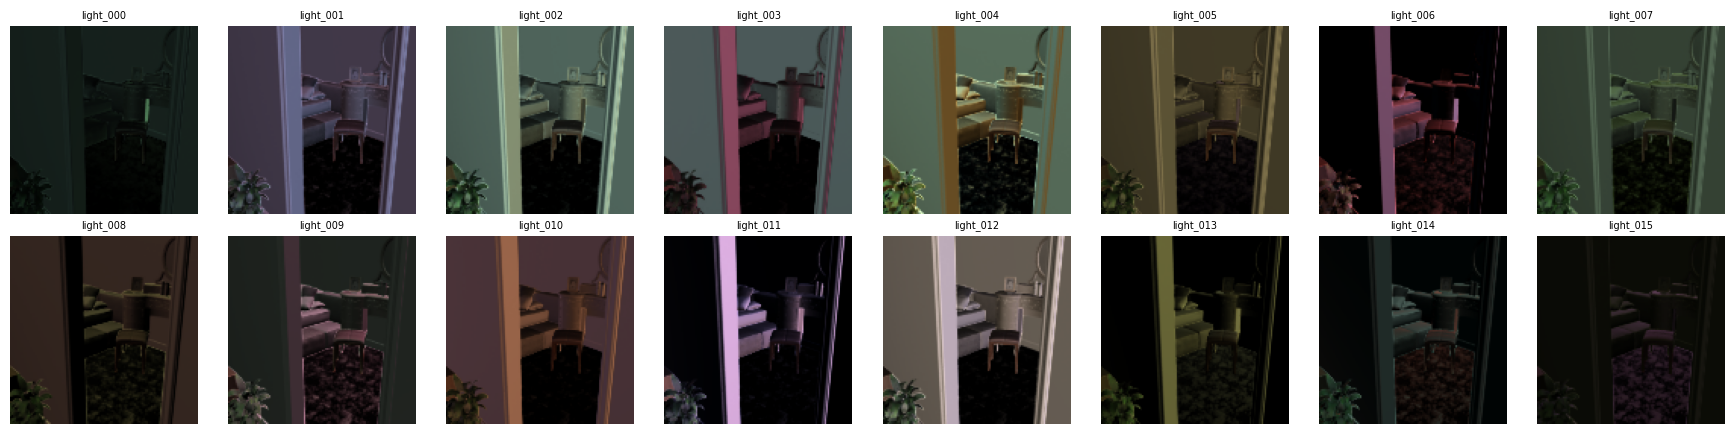

In [8]:
# -- 10b: visualize rendered images ------------------------------------
imgs = sorted(DFRONT_DATASET_ROOT.glob("light_*.png"))
n = len(imgs)
cols = min(n, 8)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.2 * rows))
for ax, p in zip(axes.flat if rows > 1 else axes, imgs):
    ax.imshow(np.array(Image.open(p)))
    ax.set_title(p.stem, fontsize=7)
    ax.axis("off")
for ax in list(axes.flat if rows > 1 else axes)[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()


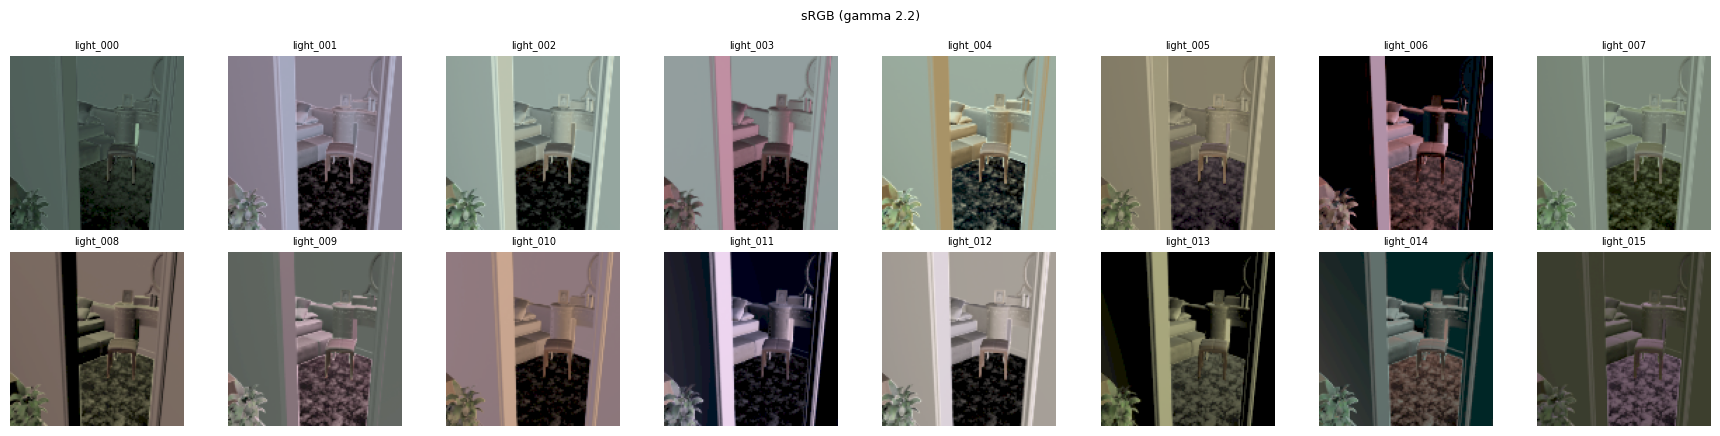

In [9]:
# -- 10b sRGB: same images tonemapped to sRGB for preview ---------------
fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.2 * rows))
for ax, p in zip(axes.flat if rows > 1 else axes, imgs):
    linear = np.array(Image.open(p)).astype(np.float32) / 255.0
    srgb = np.clip(linear, 0, 1) ** (1 / 2.2)
    ax.imshow((srgb * 255).astype(np.uint8))
    ax.set_title(p.stem, fontsize=7)
    ax.axis("off")
for ax in list(axes.flat if rows > 1 else axes)[n:]:
    ax.axis("off")
plt.suptitle("sRGB (gamma 2.2)", fontsize=9)
plt.tight_layout()
plt.show()


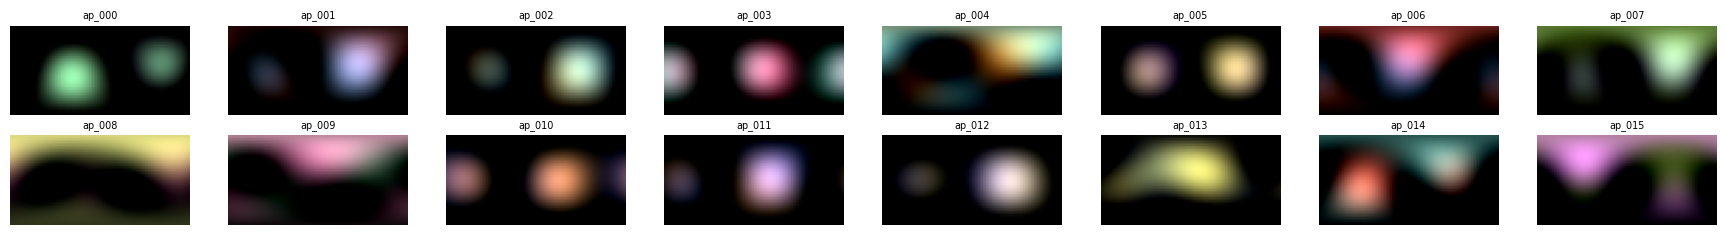

In [9]:
# -- 10c: visualize SH env maps ----------------------------------------
sh_maps = sorted(DFRONT_DATASET_ROOT.glob("sh_env_map_*.png"))
n = len(sh_maps)
cols = min(n, 8)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 1.2 * rows))
for ax, p in zip(axes.flat if rows > 1 else axes, sh_maps):
    ax.imshow(np.array(Image.open(p)))
    ax.set_title(p.stem[-6:], fontsize=7)
    ax.axis("off")
for ax in list(axes.flat if rows > 1 else axes)[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()


In [6]:
# -- 10d: CT-SH + TV decomposition on random SH dataset ---------------
decompose_scene(
    DFRONT_DATASET_ROOT, DFRONT_DATASET_ROOT.parent / "random_sh_ct_sh_tv1e-3",
    shader="ct_sh",
    cfg_overrides={"n_iter": 400, "lbfgs_max_iter": 10, "log_every": 5,
                   "lambda_tv": 1e-3},
    log_gradients=False, device=DEVICE,
    wandb_project="3dfront-decomposition",
)
print("done: CT-SH + TV decomp on random SH dataset")


NameError: name 'DFRONT_DATASET_ROOT' is not defined

--- backup_random_sh_ct_sh_tv1e-3 ---
  recon_rmse: 0.0014
  albedo_rmse: 0.0490
  final_loss: 0.0001
  metallic_est_mean: 0.1503
  metallic_gt: 0.1353
  roughness_est_mean: 0.6134
  roughness_gt: 0.4324


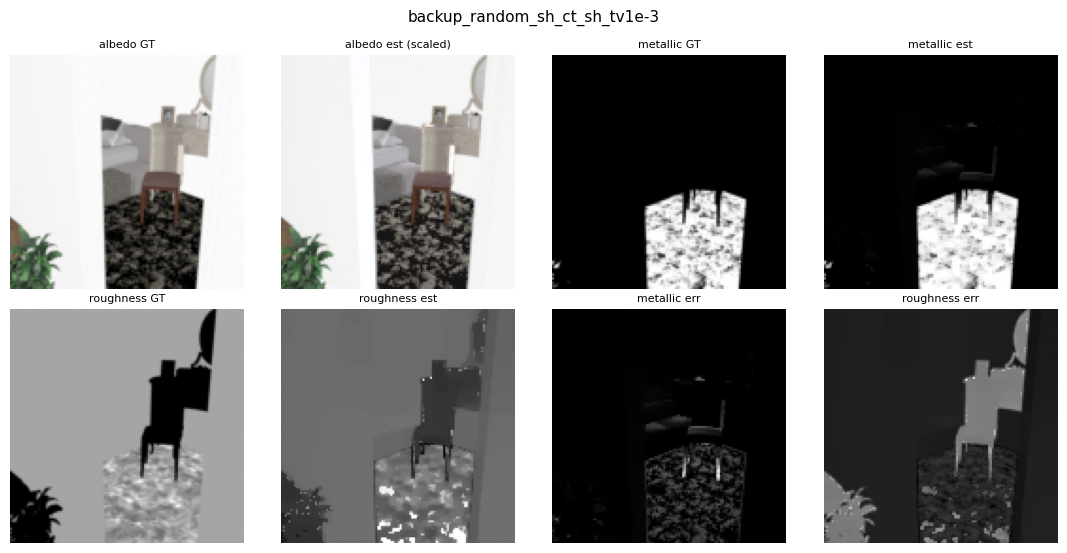

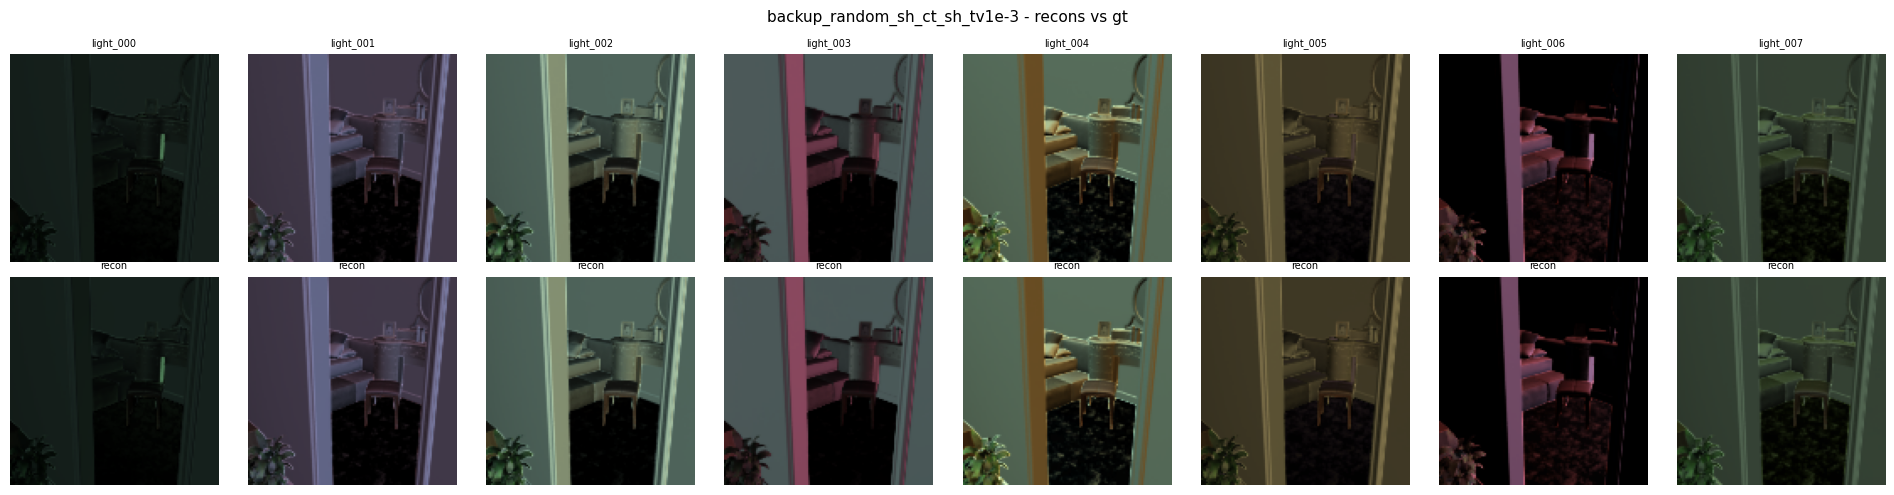

In [12]:
# -- 10e: inspect results ----------------------------------------------
show_3dfront_results(DFRONT_DATASET_ROOT.parent / "backup_random_sh_ct_sh_tv1e-3")


## 11 -- 3D-Front decomposition variants: init_spec_zero / metallic L1

**11a** -- CT-SH with `init_spec_zero=True`: metallic and roughness initialized to 0 and 1
respectively, matching a pure-diffuse prior.

**11b** -- CT-SH + TV with `lambda_metallic_l1=0.01`: L1 penalty on metallic values
toward a non-metallic (0) prior.

In [14]:
# -- 11a: CT-SH with init_spec_zero ---------------------------------
decompose_scene(
    DFRONT_DATASET_ROOT, DFRONT_DATASET_ROOT.parent / "ct_sh_tv1e-3_init_spec_zero",
    shader="ct_sh",
    cfg_overrides={"n_iter": 300, "lbfgs_max_iter": 10, "log_every": 5,
                   "init_spec_zero": True, "lambda_tv": 1e-3},
    log_gradients=False, device=DEVICE,
    wandb_project="3dfront-decomposition",
)
print("done: CT-SH init_spec_zero")


albedo_rmse,█▆▂▂▁
elapsed_s,▁▃▄▆█
loss,█▁▁▁▁
loss_data,█▁▁▁▁
loss_metallic_l1,▁▁▁▁▁
loss_sparse,▁▁▁▁▁
loss_tv,▁▁▁▁▁
loss_white,▁▁▁▁▁
lr,▁▁▁▁▁
metallic_mean,▁▄▇██
+3,...


  [init]          loss=4.486e-01  data=4.485e-01  metallic=0.000  roughness=1.000
  [   0]    2.0s  loss=8.377e-03  data=8.351e-03  metallic=0.001  roughness=0.996
  [   5]   12.1s  loss=1.179e-03  data=1.095e-03  metallic=0.022  roughness=0.964
  [  10]   23.3s  loss=8.097e-04  data=7.001e-04  metallic=0.046  roughness=0.937
  [  15]   35.0s  loss=5.984e-04  data=4.680e-04  metallic=0.086  roughness=0.906
  [  20]   46.8s  loss=4.328e-04  data=3.028e-04  metallic=0.116  roughness=0.878
  [  25]   58.2s  loss=3.470e-04  data=2.263e-04  metallic=0.133  roughness=0.863
  [  30]   70.0s  loss=3.049e-04  data=1.960e-04  metallic=0.140  roughness=0.852
  [  35]   81.4s  loss=2.729e-04  data=1.738e-04  metallic=0.145  roughness=0.843
  [  40]   92.1s  loss=2.499e-04  data=1.598e-04  metallic=0.150  roughness=0.835
  [  45]  103.7s  loss=2.294e-04  data=1.459e-04  metallic=0.155  roughness=0.826
  [  50]  115.2s  loss=2.135e-04  data=1.335e-04  metallic=0.159  roughness=0.817
  [  55]  126.6s

albedo_rmse,██▇▃▂▁▁▂▂▂▃▃▃▃▃▃▃▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
elapsed_s,▁▁▁▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇██████████
final_loss,▁
loss,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss_data,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss_metallic_l1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss_sparse,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss_tv,▂▅██▇▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
loss_white,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+5,...


  583.7s  albedo RMSE=0.0449  metallic=0.149(GT=0.135)  roughness=0.611(GT=0.432)  -> results\ct_sh_tv1e-3_init_spec_zero
done: CT-SH init_spec_zero


In [ ]:
# -- 11b: CT-SH + TV + metallic L1 (lambda=0.01) --------------------
decompose_scene(
    DFRONT_DATASET_ROOT, DFRONT_DATASET_ROOT.parent / "ct_sh_tv1e-3_metal_l1_1e-3",
    shader="ct_sh",
    cfg_overrides={"n_iter": 300, "lbfgs_max_iter": 10, "log_every": 5,
                   "lambda_tv": 1e-3, "lambda_metallic_l1": 1e-3},
    log_gradients=False, device=DEVICE,
    wandb_project="3dfront-decomposition",
)
print("done: CT-SH + TV + metallic L1")


  [init]          loss=4.526e-01  data=4.521e-01  metallic=0.500  roughness=0.500
  [   0]    2.0s  loss=5.907e-03  data=5.369e-03  metallic=0.498  roughness=0.493


In [ ]:
# -- 11c: inspect results ------------------------------------------
for run in ("ct_sh_init_spec_zero", "ct_sh_tv1e-3_metal_l1_1e-3"):
    show_3dfront_results(DFRONT_DATASET_ROOT.parent / run)
